# Early Detection of Cervical Cancer with Machine Learning

## Classification on the UCI Cervical Cancer (Risk Factors) dataset

### Problem description

**Cervical cancer** is one of the leading causes of cancer mortality in women, despite being **preventable and treatable** when detected early. The definitive diagnosis is made through a **biopsy**, an invasive procedure. The goal of this project is to build a model that can **estimate the risk of a positive biopsy result** from demographic, lifestyle, and clinical-history risk factors, so it can serve as a **screening support tool** (prioritizing which patients to refer for further studies).

### Objectives

1. **Clean and explore** the dataset (missing values encoded as `"?"`, types, distributions).
2. Perform an **exploratory data analysis (EDA)** that characterizes the problem (strong **class imbalance**).
3. **Preprocess** the data avoiding *data leakage* (imputation, scaling, and balancing inside *pipelines*).
4. Compare **feature selection methods** (univariate, model-based, and **genetic algorithms**).
5. Train and compare **≥ 3 classifiers**, tune hyperparameters, and evaluate them with metrics suitable for imbalanced data (**Recall, PR-AUC, ROC-AUC**).
6. **Interpret** the best model (SHAP) in clinical terms and draw **conclusions**.

### Key clinical consideration
> In cancer screening, a **false negative** (failing to detect a sick patient) is **much more serious** than a false positive. We therefore prioritize **Recall** and **PR-AUC** over *accuracy*.

# Setup

Dependency installation (optional if you already ran `pip install -r requirements.txt`) and project imports.

In [1]:
# Uncomment the following line the first time you run the notebook in a clean environment:
# %pip install pandas numpy scipy scikit-learn matplotlib seaborn missingno imbalanced-learn xgboost lightgbm shap deap

In [2]:
# --- Standard libraries ---
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Global configuration for reproducibility and style ---
RANDOM_STATE = 42            # global seed -> reproducible results
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")     # silence convergence/version warnings for a clean notebook

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)

print("Environment initialized. Global seed =", RANDOM_STATE)

Environment initialized. Global seed = 42


In [3]:
# --- Scikit-learn ---
from sklearn.model_selection import (train_test_split, StratifiedKFold, RandomizedSearchCV,
                                     cross_val_score, cross_val_predict)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFECV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay)

# --- Imbalance handling (imbalanced-learn) ---
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline   # Pipeline that integrates SMOTE without leakage

# --- Gradient boosting ---
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("Modeling imports loaded successfully.")

Modeling imports loaded successfully.


# Data Loading and Cleaning

The dataset encodes missing values as the string `"?"`. We convert them to `NaN` and force every column to a numeric type before any analysis.

In [4]:
def load_data(path="risk_factors_cervical_cancer.csv"):
    '''Load the CSV treating '?' as missing and convert everything to numeric.'''
    # na_values="?" -> pandas reads each '?' directly as NaN
    df = pd.read_csv(path, na_values="?")
    # Ensure ALL columns are numeric (coerce -> non-convertible becomes NaN)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

df = load_data()
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 858 rows × 36 columns


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0


In [5]:
# Data types: after cleaning all should be float/int (none 'object')
print("Data types (count):")
print(df.dtypes.value_counts())
print("\nDid any column remain as text (object)?:",
      (df.dtypes == "object").any())

Data types (count):
float64    26
int64      10
Name: count, dtype: int64

Did any column remain as text (object)?: False


### Interpretation
The dataset has **858 rows × 36 columns** and, after `"?"→NaN` + numeric conversion, all columns are numeric. The initial cleaning was successful.

# Data Analysis

## Missing values

In [6]:
missing = df.isna().sum()
pct_missing = (missing / len(df) * 100).round(2)
missing_table = (pd.DataFrame({"n_missing": missing, "pct_missing": pct_missing})
                   .query("n_missing > 0")
                   .sort_values("pct_missing", ascending=False))
missing_table

,n_missing,pct_missing
STDs: Time since last diagnosis,787,91.72
STDs: Time since first diagnosis,787,91.72
IUD,117,13.64
IUD (years),117,13.64
Hormonal Contraceptives,108,12.59
Hormonal Contraceptives (years),108,12.59
STDs:vulvo-perineal condylomatosis,105,12.24
STDs:HPV,105,12.24
STDs:Hepatitis B,105,12.24
STDs:HIV,105,12.24


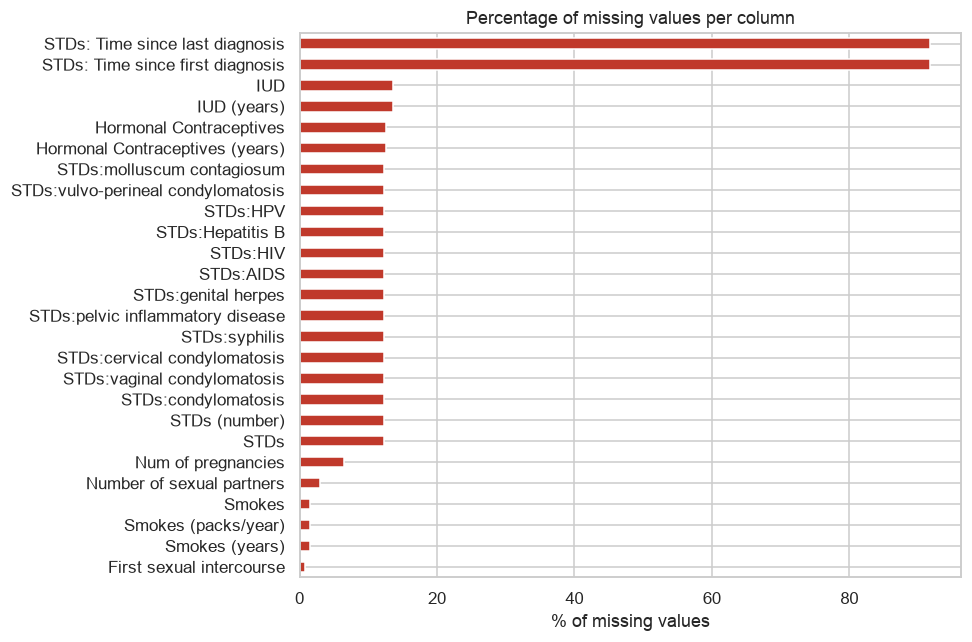

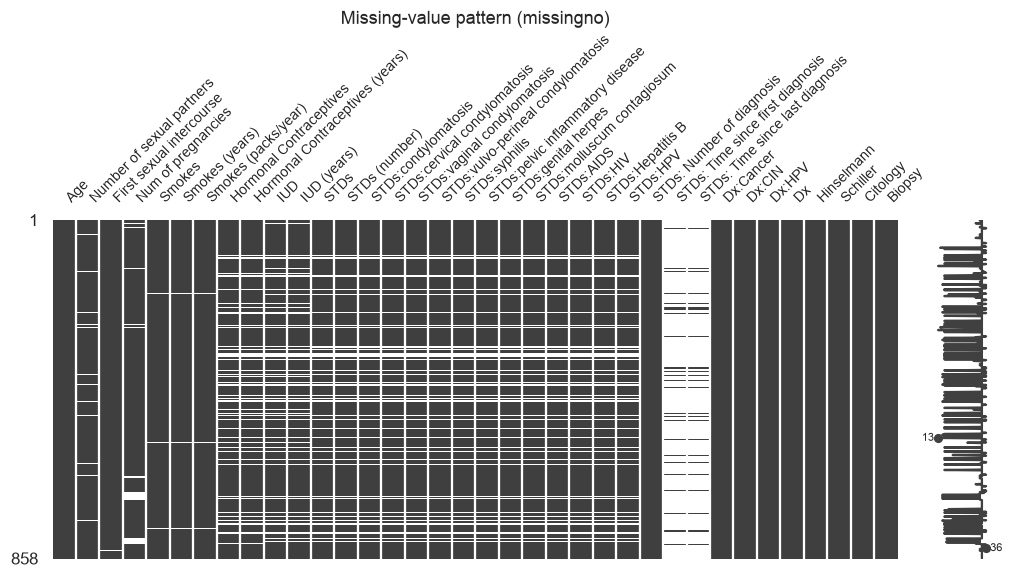

In [7]:
# Bar chart of the % of nulls per column (we use missingno if available)
fig, ax = plt.subplots(figsize=(9, 6))
missing_table["pct_missing"].sort_values().plot.barh(ax=ax, color="#c0392b")
ax.set_xlabel("% of missing values")
ax.set_title("Percentage of missing values per column")
plt.tight_layout(); plt.show()

# Null matrix with missingno (missingness pattern)
try:
    import missingno as msno
    msno.matrix(df, figsize=(11, 4), fontsize=9)
    plt.title("Missing-value pattern (missingno)"); plt.show()
except Exception as e:
    print("missingno not available:", e)

### Interpretation of missing values
- `STDs: Time since first/last diagnosis` have **~92%** missing ⇒ they are dropped (see *Data Transformation*).
- The STDs / hormonal / IUD block is around **12–14%**: an imputable level.
- Missing values concentrate in the same rows (patients who did not answer that questionnaire section).

## Distribution of continuous variables

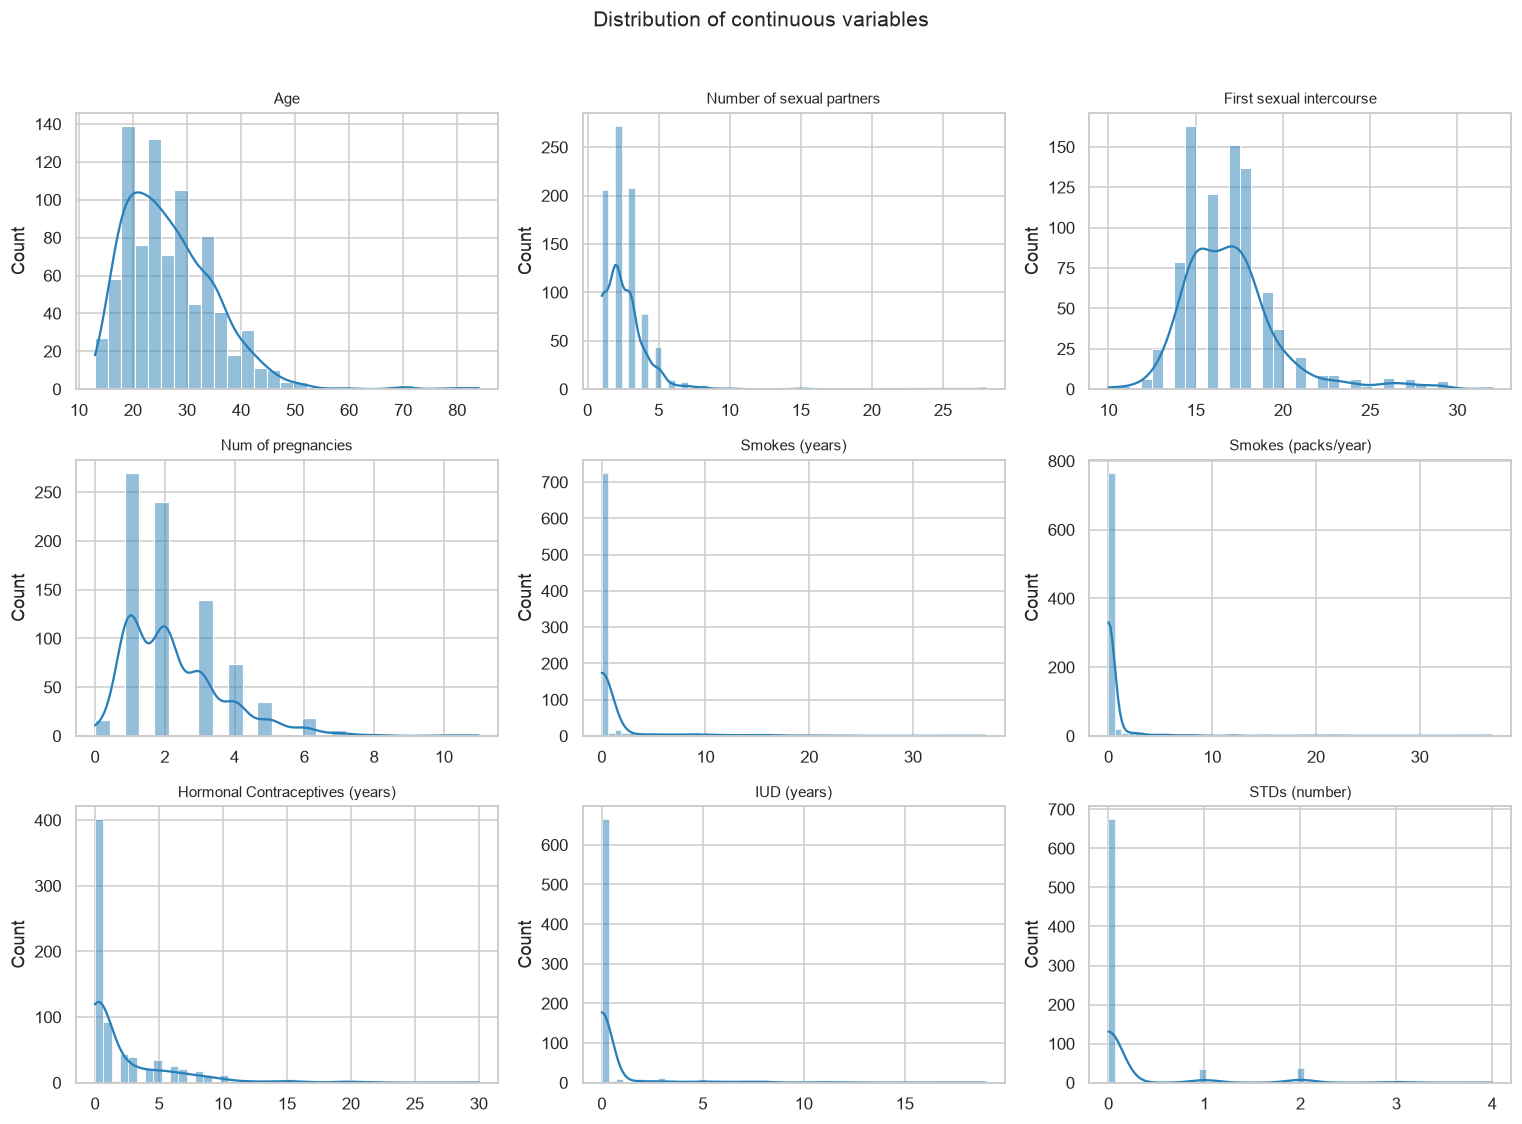

Skewness of the continuous variables:
Smokes (packs/year)                9.31
Number of sexual partners          5.45
IUD (years)                        5.00
Smokes (years)                     4.47
STDs (number)                      3.40
Hormonal Contraceptives (years)    2.63
First sexual intercourse           1.56
Num of pregnancies                 1.42
Age                                1.39
dtype: float64


In [8]:
continuous = ["Age", "Number of sexual partners", "First sexual intercourse",
              "Num of pregnancies", "Smokes (years)", "Smokes (packs/year)",
              "Hormonal Contraceptives (years)", "IUD (years)", "STDs (number)"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), continuous):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#2980b9")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.suptitle("Distribution of continuous variables", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

# Numeric skewness
print("Skewness of the continuous variables:")
print(df[continuous].skew().round(2).sort_values(ascending=False))

### Interpretation of the distributions
Strong **right skew** in most variables (`Age` concentrated around ~15–35 years; many with an excess of zeros and a long tail). This justifies **scaling** for linear models; tree-based models are scale-insensitive.

## Outlier detection

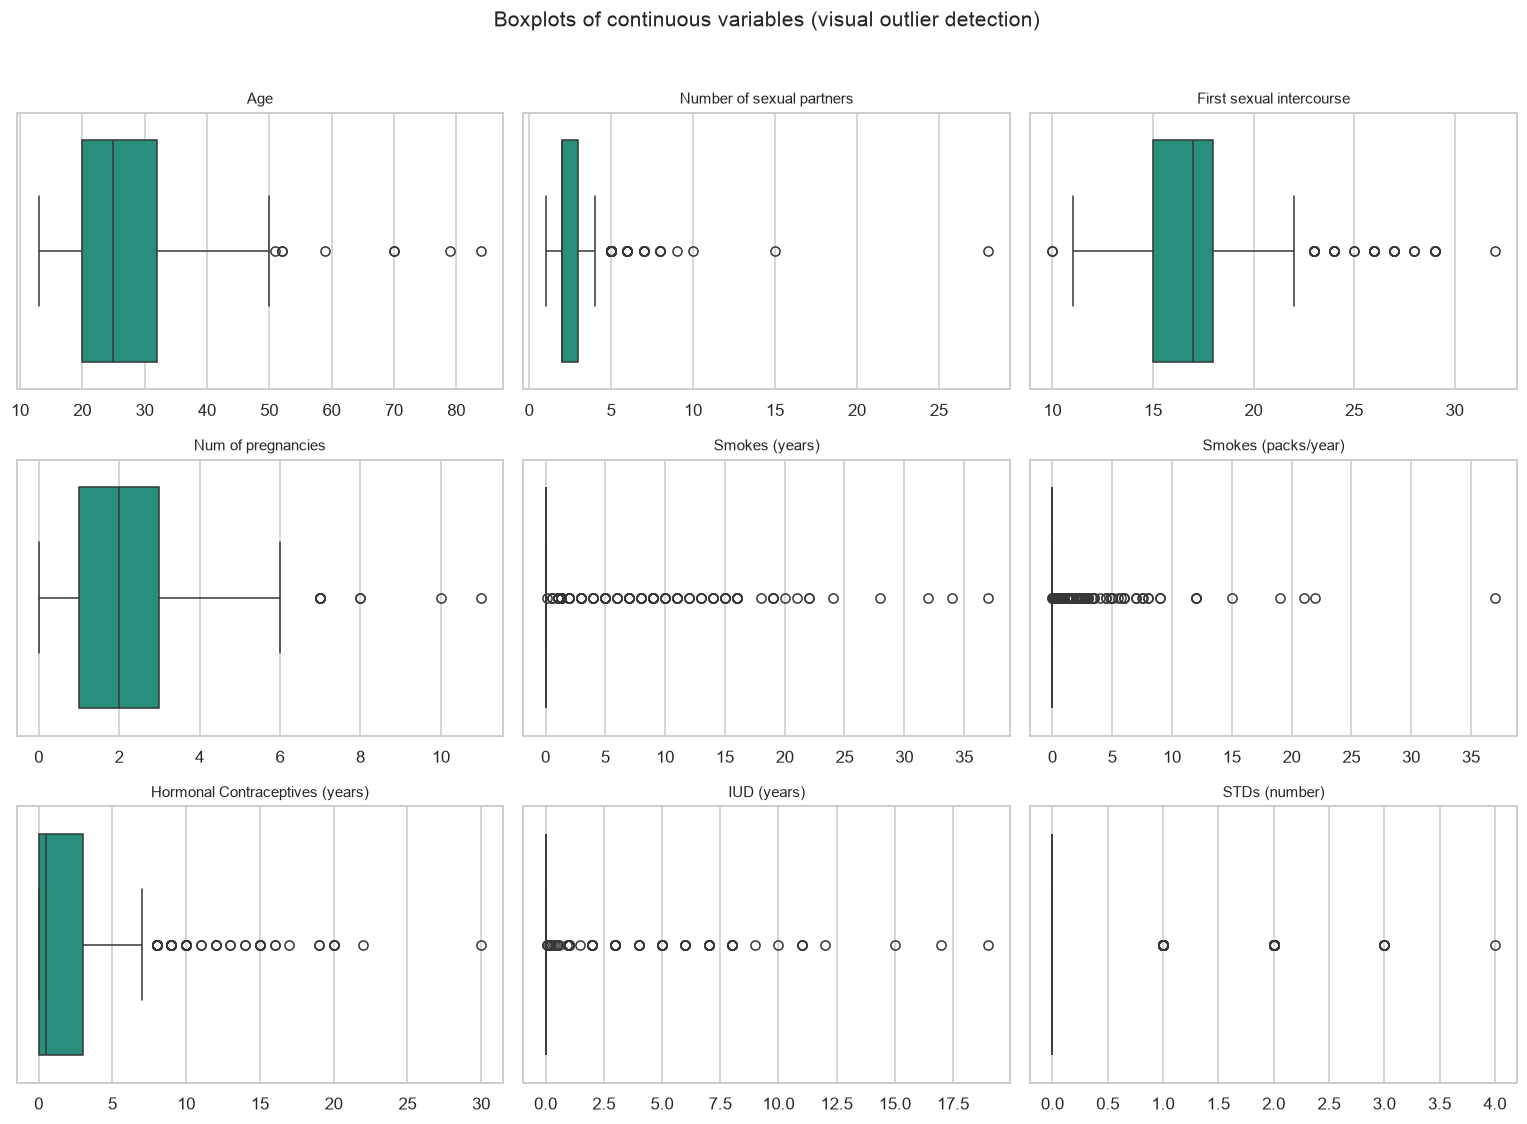

,n_outliers_IQR
Smokes (years),123
Smokes (packs/year),123
IUD (years),83
STDs (number),79
Number of sexual partners,68
Hormonal Contraceptives (years),68
First sexual intercourse,41
Num of pregnancies,10
Age,8


In [9]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), continuous):
    sns.boxplot(x=df[col], ax=ax, color="#16a085")
    ax.set_title(col, fontsize=10); ax.set_xlabel("")
plt.suptitle("Boxplots of continuous variables (visual outlier detection)", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

def count_outliers_iqr(series):
    '''Count outliers using the interquartile-range rule (1.5*IQR).'''
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < low) | (series > high)).sum())

outliers_summary = pd.DataFrame({
    "n_outliers_IQR": [count_outliers_iqr(df[c].dropna()) for c in continuous]
}, index=continuous).sort_values("n_outliers_IQR", ascending=False)
outliers_summary

### Outlier interpretation — decision: keep them
The IQR method detects extremes in almost every variable, but we **keep them**: they are clinically plausible cases (not errors), tend to be the most informative about the positive class, and with only 55 positives we cannot afford to lose rows. We mitigate this with robust models (trees/boosting) and scaling for the linear ones.

## Class imbalance (target variable `Biopsy`)

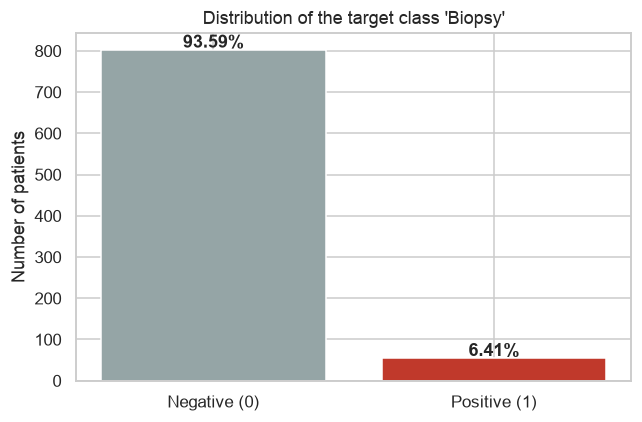

Biopsy
0    803
1     55
Name: count, dtype: int64

Positive-class proportion: 6.41%


In [10]:
target = "Biopsy"
counts = df[target].value_counts().sort_index()
pct = (counts / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Negative (0)", "Positive (1)"], counts.values,
              color=["#95a5a6", "#c0392b"])
for b, p in zip(bars, pct.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height()+5, f"{p}%",
            ha="center", fontweight="bold")
ax.set_title(f"Distribution of the target class '{target}'")
ax.set_ylabel("Number of patients")
plt.tight_layout(); plt.show()

print(counts)
print(f"\nPositive-class proportion: {pct[1]}%")

### Why accuracy is misleading here
Only **~6.4%** of biopsies are positive: a model that always predicts "negative" would be right ~93.6% of the time but with **Recall = 0**. We therefore evaluate with **Recall**, **PR-AUC**, and **ROC-AUC**, not accuracy.

## Correlations

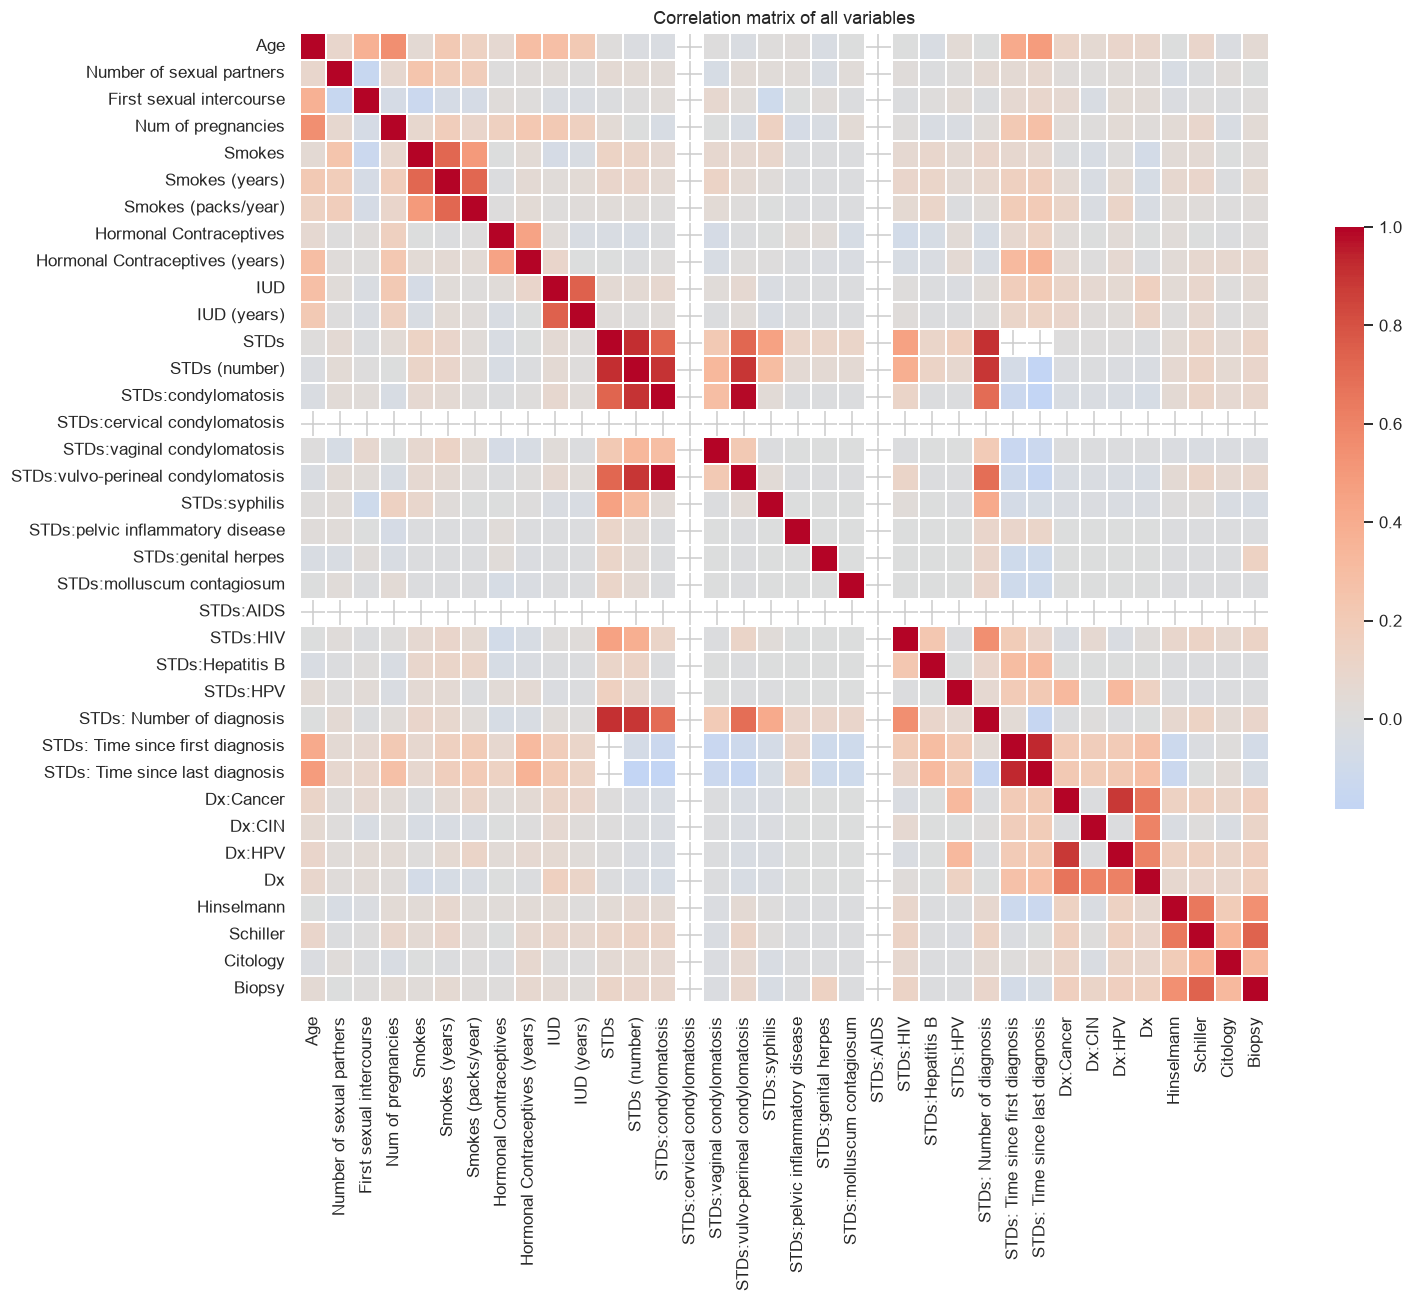

FEATURE pairs with |correlation| > 0.8:
STDs:condylomatosis               STDs:vulvo-perineal condylomatosis    0.988
STDs: Time since first diagnosis  STDs: Time since last diagnosis       0.931
STDs                              STDs (number)                         0.919
                                  STDs: Number of diagnosis             0.907
STDs (number)                     STDs:condylomatosis                   0.900
                                  STDs: Number of diagnosis             0.897
                                  STDs:vulvo-perineal condylomatosis    0.891
Dx:Cancer                         Dx:HPV                                0.887
dtype: float64


In [11]:
plt.figure(figsize=(15, 12))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.6}, linewidths=0.3)
plt.title("Correlation matrix of all variables")
plt.tight_layout(); plt.show()

# Highly correlated feature pairs (excluding diagnostic tests), |r| > 0.8
dx_tests = ["Hinselmann", "Schiller", "Citology", "Biopsy"]
corr_feats = df.drop(columns=dx_tests).corr().abs()
pairs = (corr_feats.where(np.triu(np.ones(corr_feats.shape), k=1).astype(bool))
                   .stack().sort_values(ascending=False))
print("FEATURE pairs with |correlation| > 0.8:")
print(pairs[pairs > 0.8].round(3))

### Interpretation of the correlations
There are **redundant blocks** (smoking; contraceptives/IUD binary vs. years; STDs). This multicollinearity affects logistic regression but not tree-based models; we address it with **feature selection**.

## Removing problematic and data-leakage columns
Based on the EDA we make two decisions before transforming:
1. **Excess missingness (~92%):** we drop `STDs: Time since first/last diagnosis`.
2. **Data leakage:** `Hinselmann`, `Schiller`, and `Citology` are other diagnostic tests for the same clinical event; they are not available before deciding on the biopsy and would leak the answer ⇒ **they are not used as features**.

In [12]:
cols_many_nan = ["STDs: Time since first diagnosis", "STDs: Time since last diagnosis"]
cols_leakage  = ["Hinselmann", "Schiller", "Citology"]   # other dx tests -> NOT features

y = df[target].astype(int)
X = df.drop(columns=cols_many_nan + cols_leakage + [target])

print(f"Final features: {X.shape[1]} columns (dropped "
      f"{len(cols_many_nan)} for NaN + {len(cols_leakage)} for leakage + the target).")
print("\nColumns used as features:")
print(list(X.columns))

Final features: 30 columns (dropped 2 for NaN + 3 for leakage + the target).

Columns used as features:
['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx']


# Data Transformation

Every transformer that learns from the data (imputer, scaler, SMOTE) is fitted **only on the training set**, inside a `Pipeline`, avoiding *data leakage* during cross-validation.
- **Imputation:** median (robust to skew).
- **Scaling:** `StandardScaler` (essential for logistic regression; harmless for trees).
- **Stratified split** to preserve the ~6.4% of positives in both partitions.
- **Imbalance:** SMOTE (synthetic oversampling of the training set) integrated into the pipeline.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} rows | positives: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Test : {X_test.shape[0]} rows | positives: {y_test.sum()} ({y_test.mean()*100:.2f}%)")
print("\nStratification keeps the same proportion of positives in train and test.")

Train: 643 rows | positives: 41 (6.38%)
Test : 215 rows | positives: 14 (6.51%)

Stratification keeps the same proportion of positives in train and test.


In [14]:
# This preprocessor is REUSED inside each model pipeline to avoid leakage.
def make_preprocessor():
    '''Return the imputation (median) + standard scaling steps.'''
    return [("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler())]

# Demonstration of SMOTE ONLY on the training set (never on test):
prep = ImbPipeline(make_preprocessor())
X_train_prep = prep.fit_transform(X_train)
sm = SMOTE(random_state=RANDOM_STATE)
X_res, y_res = sm.fit_resample(X_train_prep, y_train)
print(f"Original train : {len(y_train)} rows -> positives {y_train.sum()}")
print(f"Train after SMOTE: {len(y_res)} rows -> positives {int(y_res.sum())} (balanced classes)")
print("\nNote: this is only illustrative. In modeling, SMOTE goes INSIDE the pipeline")
print("so that cross-validation applies it fold by fold without contaminating validation.")

Original train : 643 rows -> positives 41
Train after SMOTE: 1204 rows -> positives 602 (balanced classes)

Note: this is only illustrative. In modeling, SMOTE goes INSIDE the pipeline
so that cross-validation applies it fold by fold without contaminating validation.


# Feature Selection

We compare three approaches, all fitted **on the training set** (with prior imputation):
1. **Univariate filtering** — `SelectKBest` (`f_classif`, `mutual_info_classif`).
2. **Model-based** — feature importances from a `RandomForest`.
3. **Genetic algorithm (GA)** — evolutionary search for the feature mask that maximizes cross-validated ROC-AUC (DEAP).

In [15]:
# Impute the training set for the selectors that don't tolerate NaN.
imp_fs = SimpleImputer(strategy="median").fit(X_train)
X_train_imp = pd.DataFrame(imp_fs.transform(X_train), columns=X.columns, index=X_train.index)
feature_names = list(X.columns)

## Univariate filtering (SelectKBest)

In [16]:
K = 12  # number of features to keep in the comparison

skb_f = SelectKBest(f_classif, k=K).fit(X_train_imp, y_train)
skb_mi = SelectKBest(lambda Xx, yy: mutual_info_classif(Xx, yy, random_state=RANDOM_STATE),
                     k=K).fit(X_train_imp, y_train)

rank_f  = pd.Series(skb_f.scores_,  index=feature_names).sort_values(ascending=False)
rank_mi = pd.Series(skb_mi.scores_, index=feature_names).sort_values(ascending=False)

top_fclassif = set(rank_f.head(K).index)
top_mi       = set(rank_mi.head(K).index)

univ_summary = pd.DataFrame({"F_classif": rank_f, "Mutual_info": rank_mi}).round(4)
print(f"Top {K} by ANOVA F-classif:\n", list(rank_f.head(K).index), "\n")
print(f"Top {K} by Mutual Information:\n", list(rank_mi.head(K).index))
univ_summary.head(15)

Top 12 by ANOVA F-classif:
 ['Dx', 'Dx:HPV', 'Dx:Cancer', 'Dx:CIN', 'STDs:HIV', 'STDs', 'STDs: Number of diagnosis', 'STDs (number)', 'STDs:vulvo-perineal condylomatosis', 'IUD', 'STDs:condylomatosis', 'Age'] 

Top 12 by Mutual Information:
 ['Dx', 'Num of pregnancies', 'STDs:condylomatosis', 'Dx:Cancer', 'Dx:CIN', 'STDs: Number of diagnosis', 'IUD', 'Dx:HPV', 'Smokes', 'STDs:HIV', 'Number of sexual partners', 'STDs:pelvic inflammatory disease']


,F_classif,Mutual_info
Age,2.4942,0.0052
Dx,25.6058,0.0237
Dx:CIN,13.3772,0.0153
Dx:Cancer,17.4129,0.0166
Dx:HPV,19.1950,0.0095
First sexual intercourse,0.0952,0.0000
Hormonal Contraceptives,0.6880,0.0000
Hormonal Contraceptives (years),2.4836,0.0000
IUD,4.9186,0.0101
IUD (years),1.7367,0.0000


## Model-based (Random Forest importances)

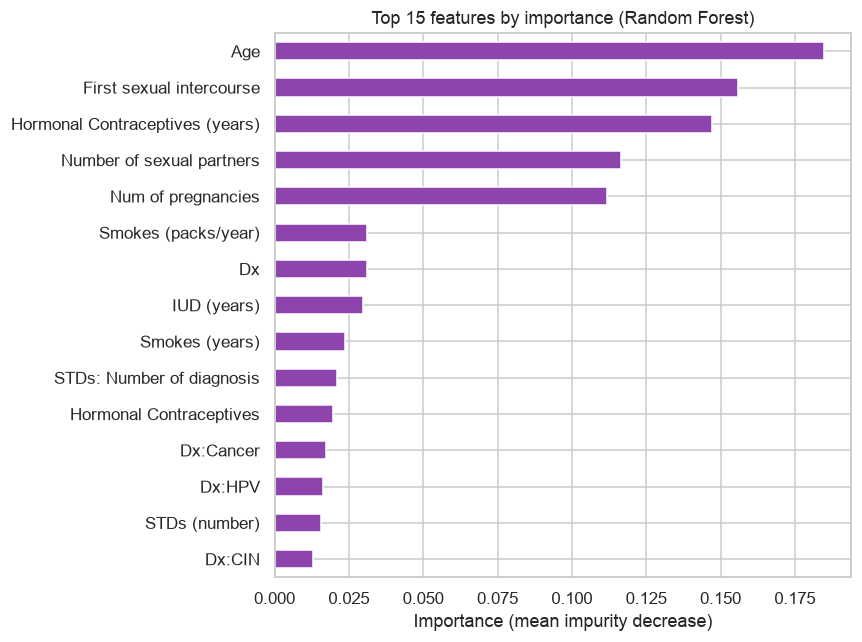

Top 12 by RF importance:
 ['Age', 'First sexual intercourse', 'Hormonal Contraceptives (years)', 'Number of sexual partners', 'Num of pregnancies', 'Smokes (packs/year)', 'Dx', 'IUD (years)', 'Smokes (years)', 'STDs: Number of diagnosis', 'Hormonal Contraceptives', 'Dx:Cancer']


In [17]:
rf_fs = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                               random_state=RANDOM_STATE, n_jobs=-1)
rf_fs.fit(X_train_imp, y_train)
imp_rf = pd.Series(rf_fs.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
imp_rf.head(15).sort_values().plot.barh(color="#8e44ad")
plt.title("Top 15 features by importance (Random Forest)")
plt.xlabel("Importance (mean impurity decrease)")
plt.tight_layout(); plt.show()

top_rf = set(imp_rf.head(K).index)
print(f"Top {K} by RF importance:\n", list(imp_rf.head(K).index))

## Genetic Algorithm (DEAP)

Each **individual** is a binary mask (1 = include the feature). The *fitness* is the **mean cross-validated ROC-AUC** of a logistic regression trained only on the active features, penalizing the number of features to favor parsimonious solutions. Operators: tournament selection, two-point crossover, and bit-flip mutation.

In [18]:
from deap import base, creator, tools, algorithms
import random
random.seed(RANDOM_STATE)

n_features = X_train_imp.shape[1]
cv_ga = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_ga = X_train_imp.values

def eval_individual(individual):
    '''Fitness = cross-validated ROC-AUC with the active features, penalizing the number of features.'''
    mask = np.array(individual, dtype=bool)
    if mask.sum() == 0:
        return (0.0,)                      # an empty mask is useless
    model = ImbPipeline([("imputer", SimpleImputer(strategy="median")),
                         ("scaler", StandardScaler()),
                         ("smote", SMOTE(random_state=RANDOM_STATE)),
                         ("clf", LogisticRegression(max_iter=1000,
                                                    random_state=RANDOM_STATE))])
    auc = cross_val_score(model, X_ga[:, mask], y_train.values,
                          cv=cv_ga, scoring="roc_auc", n_jobs=-1).mean()
    penalty = 0.001 * mask.sum()           # reward parsimony
    return (auc - penalty,)

# DEAP configuration (guarded so the cell can be re-run without 'creator' errors)
if not hasattr(creator, "FitnessMax"):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual,
                 toolbox.attr_bool, n_features)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", eval_individual)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=20)             # small population -> fast notebook
hof = tools.HallOfFame(1)                  # keeps the best individual
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max", np.max); stats.register("avg", np.mean)

print("Running genetic algorithm (this may take ~1-2 min)...")
pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2,
                                   ngen=12, stats=stats, halloffame=hof, verbose=False)

best_mask = np.array(hof[0], dtype=bool)
features_ga = [f for f, m in zip(feature_names, best_mask) if m]
print(f"\nGA finished. Best ROC-AUC (CV) ≈ {hof[0].fitness.values[0]:.4f}")
print(f"Features selected by the GA ({len(features_ga)} of {n_features}):")
print(features_ga)

Running genetic algorithm (this may take ~1-2 min)...



GA finished. Best ROC-AUC (CV) ≈ 0.7158
Features selected by the GA (10 of 30):
['Num of pregnancies', 'Hormonal Contraceptives (years)', 'STDs (number)', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:genital herpes', 'STDs:AIDS', 'STDs:HIV', 'Dx:CIN', 'Dx:HPV']


## Comparison of the methods

In [19]:
# We compare which features each method chooses and which are "consensus".
sel_methods = {"F_classif": top_fclassif, "Mutual_info": top_mi,
               "RandomForest": top_rf, "GA": set(features_ga)}
sel_table = pd.DataFrame({m: [f in s for f in feature_names] for m, s in sel_methods.items()},
                         index=feature_names)
sel_table["n_methods"] = sel_table.sum(axis=1)
sel_table = sel_table.sort_values("n_methods", ascending=False)
print("Features sorted by number of methods that select them:")
sel_table

Features sorted by number of methods that select them:


,F_classif,Mutual_info,RandomForest,GA,n_methods
Dx,True,True,True,False,3
Dx:HPV,True,True,False,True,3
Num of pregnancies,False,True,True,True,3
Dx:CIN,True,True,False,True,3
Dx:Cancer,True,True,True,False,3
STDs: Number of diagnosis,True,True,True,False,3
STDs:HIV,True,True,False,True,3
STDs (number),True,False,False,True,2
STDs:vulvo-perineal condylomatosis,True,False,False,True,2
Number of sexual partners,False,True,True,False,2


### Interpretation of the feature selection
- The variables that agree across several methods (`Age`, `Dx:*`, `Hormonal Contraceptives (years)`, `First sexual intercourse`, `Number of sexual partners`, `STDs (number)`) are the most robust.
- The **GA** finds a more compact subset with comparable ROC-AUC, since it evaluates combinations of features (interactions) rather than each variable in isolation.
- **Decision:** we train with **all features** and use the GA subset as a comparative configuration in the tests.

# Models Used

Each model is an `imblearn.Pipeline` chaining `imputation → scaling → SMOTE → classifier`, so that SMOTE and scaling are fitted **only on the training fold** during cross-validation.

## Logistic Regression
Interpretable linear baseline.

## Random Forest
Tree ensemble, robust and non-linear.

## XGBoost
Gradient boosting, powerful on tabular data.

## LightGBM
Efficient gradient boosting (the modern approach for tabular data).

In [20]:
def build_pipeline(classifier):
    '''Wrap imputation + scaling + SMOTE + a classifier in a leakage-free pipeline.'''
    return ImbPipeline([("imputer", SimpleImputer(strategy="median")),
                        ("scaler",  StandardScaler()),
                        ("smote",   SMOTE(random_state=RANDOM_STATE)),
                        ("clf",     classifier)])

models = {
    "Logistic Regression": build_pipeline(
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "Random Forest": build_pipeline(
        RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    "XGBoost": build_pipeline(
        XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                      eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)),
    "LightGBM": build_pipeline(
        LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE,
                       n_jobs=-1, verbose=-1)),
}
print("Defined models:", list(models.keys()))

Defined models: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']


In [21]:
def evaluate_model(name, model, X_te, y_te, threshold=0.5):
    '''Compute the full metric package using a configurable decision threshold.'''
    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)   # default threshold 0.5; tuned later
    return {
        "Model":     name,
        "Threshold": round(float(threshold), 3),
        "Accuracy":  accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall":    recall_score(y_te, y_pred, zero_division=0),
        "F1":        f1_score(y_te, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_te, y_proba),
        "PR-AUC":    average_precision_score(y_te, y_proba),
    }

def choose_threshold(model, X_tr, y_tr, cv):
    '''Choose the threshold that maximizes F1 using cross-validated probabilities from the TRAIN set.

    Obtaining the threshold from the training set itself (via cross_val_predict) avoids the data leakage
    that would come from tuning it while looking at the test set.'''
    proba_cv = cross_val_predict(model, X_tr, y_tr, cv=cv,
                                 method="predict_proba", n_jobs=-1)[:, 1]
    prec, rec, thr = precision_recall_curve(y_tr, proba_cv)
    f1s = 2 * prec * rec / (prec + rec + 1e-9)      # F1 at each cut-off point
    return float(thr[np.argmax(f1s[:-1])]) if len(thr) else 0.5

# Baseline training + evaluation (before hyperparameter tuning)
base_results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    base_results.append(evaluate_model(name, model, X_test, y_test))

base_table = pd.DataFrame(base_results).set_index("Model").round(4)
base_table.sort_values("PR-AUC", ascending=False)

,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,,
Random Forest,0.5,0.9256,0.2500,0.0714,0.1111,0.7496,0.1982
LightGBM,0.5,0.9302,0.3333,0.0714,0.1176,0.6912,0.1811
Logistic Regression,0.5,0.7860,0.0789,0.2143,0.1154,0.5338,0.1752
XGBoost,0.5,0.9209,0.0000,0.0000,0.0000,0.6876,0.1343


### Interpretation of the baseline models
With the **default decision threshold (0.5)**, although PR-AUC and ROC-AUC (threshold-independent) are reasonable, **Recall can collapse** because the models rarely assign a probability > 0.5 to the minority class. This motivates **hyperparameter tuning** (optimizing PR-AUC) and **adjusting the threshold** to the clinical context. We sort by **PR-AUC**.

# Tests with All Features

## Hyperparameter tuning
`RandomizedSearchCV` with `StratifiedKFold` (preserves the imbalance in each fold) and `scoring="average_precision"` (PR-AUC). It optimizes the classifier's hyperparameters inside the pipeline (prefix `clf__`), without *leakage*.

In [22]:
cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_spaces = {
    "Random Forest": {
        "clf__n_estimators": [200, 300, 500],
        "clf__max_depth": [None, 5, 10, 20],
        "clf__min_samples_leaf": [1, 2, 4],
        "clf__max_features": ["sqrt", "log2", 0.5],
    },
    "XGBoost": {
        "clf__n_estimators": [200, 400, 600],
        "clf__max_depth": [3, 4, 6],
        "clf__learning_rate": [0.01, 0.05, 0.1],
        "clf__subsample": [0.7, 0.85, 1.0],
        "clf__colsample_bytree": [0.7, 0.85, 1.0],
    },
    "LightGBM": {
        "clf__n_estimators": [200, 400, 600],
        "clf__num_leaves": [15, 31, 63],
        "clf__learning_rate": [0.01, 0.05, 0.1],
        "clf__subsample": [0.7, 0.85, 1.0],
    },
}

best_models = {"Logistic Regression": models["Logistic Regression"]}  # baseline without tuning
for name, space in param_spaces.items():
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(build_pipeline(models[name].named_steps["clf"]),
                                param_distributions=space, n_iter=20,
                                scoring="average_precision", cv=cv_tune,
                                random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    print(f"  Best PR-AUC (CV) = {search.best_score_:.4f}")
    print(f"  Best hyperparameters: {search.best_params_}\n")

Tuning Random Forest...


  Best PR-AUC (CV) = 0.1763
  Best hyperparameters: {'clf__n_estimators': 500, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 20}

Tuning XGBoost...


  Best PR-AUC (CV) = 0.1328
  Best hyperparameters: {'clf__subsample': 0.7, 'clf__n_estimators': 600, 'clf__max_depth': 6, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.7}

Tuning LightGBM...


  Best PR-AUC (CV) = 0.1473
  Best hyperparameters: {'clf__subsample': 0.7, 'clf__num_leaves': 15, 'clf__n_estimators': 600, 'clf__learning_rate': 0.01}



### Effect of the hyperparameters
- **`n_estimators` / `learning_rate`:** their product controls the effective capacity of the boosting.
- **`max_depth` / `num_leaves`:** limit complexity and reduce overfitting (critical with only 55 positives).
- **`subsample` / `colsample_bytree`:** add regularization and diversity.
- **`min_samples_leaf` (RF):** prevents memorizing individual cases.

The search was guided by **cross-validated PR-AUC**.

## Final evaluation and comparison

We retrain each best model on the whole training set and evaluate it on the **untouched test set**: the full metric package, **confusion matrix**, and **ROC and Precision-Recall curves**. We also **tune the decision threshold** by maximizing F1 on cross-validated training probabilities (without looking at the test set), so that Recall is clinically useful.

## Variant with the Genetic Algorithm features

As an additional comparison, we add a **LightGBM + GA features** variant to measure the value of the evolutionary selection versus using all features.

In [23]:
lgbm_ga = build_pipeline(LGBMClassifier(n_estimators=400, learning_rate=0.05,
                                        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
lgbm_ga.fit(X_train[features_ga], y_train)

# Final training + threshold tuning (from the train set, no leakage) for each model
final_results = []
trained_models = {}
thresholds = {}
for name, model in best_models.items():
    thresholds[name] = choose_threshold(model, X_train, y_train, cv_tune)  # optimal threshold via CV
    model.fit(X_train, y_train)
    trained_models[name] = model
    final_results.append(evaluate_model(name, model, X_test, y_test, thresholds[name]))

# GA variant (features selected by the genetic algorithm), with its own threshold
thresholds["LightGBM + GA feats"] = choose_threshold(lgbm_ga, X_train[features_ga], y_train, cv_tune)
final_results.append(evaluate_model("LightGBM + GA feats", lgbm_ga,
                                    X_test[features_ga], y_test,
                                    thresholds["LightGBM + GA feats"]))
trained_models["LightGBM + GA feats"] = lgbm_ga

final_table = (pd.DataFrame(final_results).set_index("Model")
                 .round(4).sort_values("PR-AUC", ascending=False))
print("=== FINAL COMPARISON TABLE (sorted by PR-AUC) ===")
final_table

=== FINAL COMPARISON TABLE (sorted by PR-AUC) ===


,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,,
Random Forest,0.324,0.8326,0.1071,0.2143,0.1429,0.7454,0.1945
Logistic Regression,0.613,0.8605,0.1364,0.2143,0.1667,0.5338,0.1752
LightGBM,0.158,0.8233,0.1250,0.2857,0.1739,0.6720,0.1592
XGBoost,0.220,0.8558,0.1304,0.2143,0.1622,0.6557,0.1244
LightGBM + GA feats,0.674,0.8977,0.1000,0.0714,0.0833,0.5027,0.0933


In [24]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
final_table.style.highlight_max(axis=0, subset=metric_cols, color="#a9dfbf")\
    .format("{:.4f}")\
    .set_caption("Final model comparison (green = best per column)")

,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,,
Random Forest,0.3240,0.8326,0.1071,0.2143,0.1429,0.7454,0.1945
Logistic Regression,0.6130,0.8605,0.1364,0.2143,0.1667,0.5338,0.1752
LightGBM,0.1580,0.8233,0.1250,0.2857,0.1739,0.6720,0.1592
XGBoost,0.2200,0.8558,0.1304,0.2143,0.1622,0.6557,0.1244
LightGBM + GA feats,0.6740,0.8977,0.1000,0.0714,0.0833,0.5027,0.0933


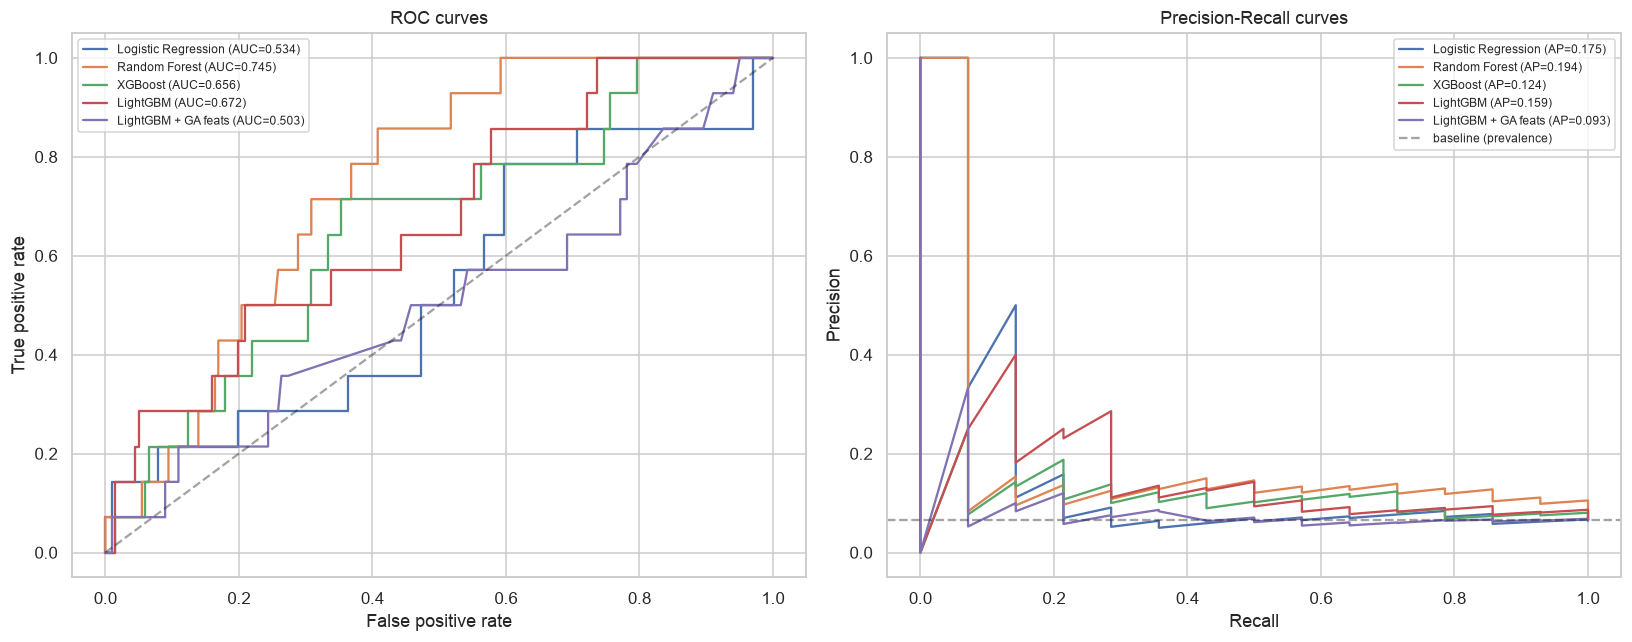

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for name, model in trained_models.items():
    Xt = X_test[features_ga] if "GA" in name else X_test
    proba = model.predict_proba(Xt)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax1.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax2.plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")

ax1.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax1.set(xlabel="False positive rate", ylabel="True positive rate",
        title="ROC curves"); ax1.legend(fontsize=8)
ax2.axhline(y_test.mean(), color="k", ls="--", alpha=0.4, label="baseline (prevalence)")
ax2.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall curves"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

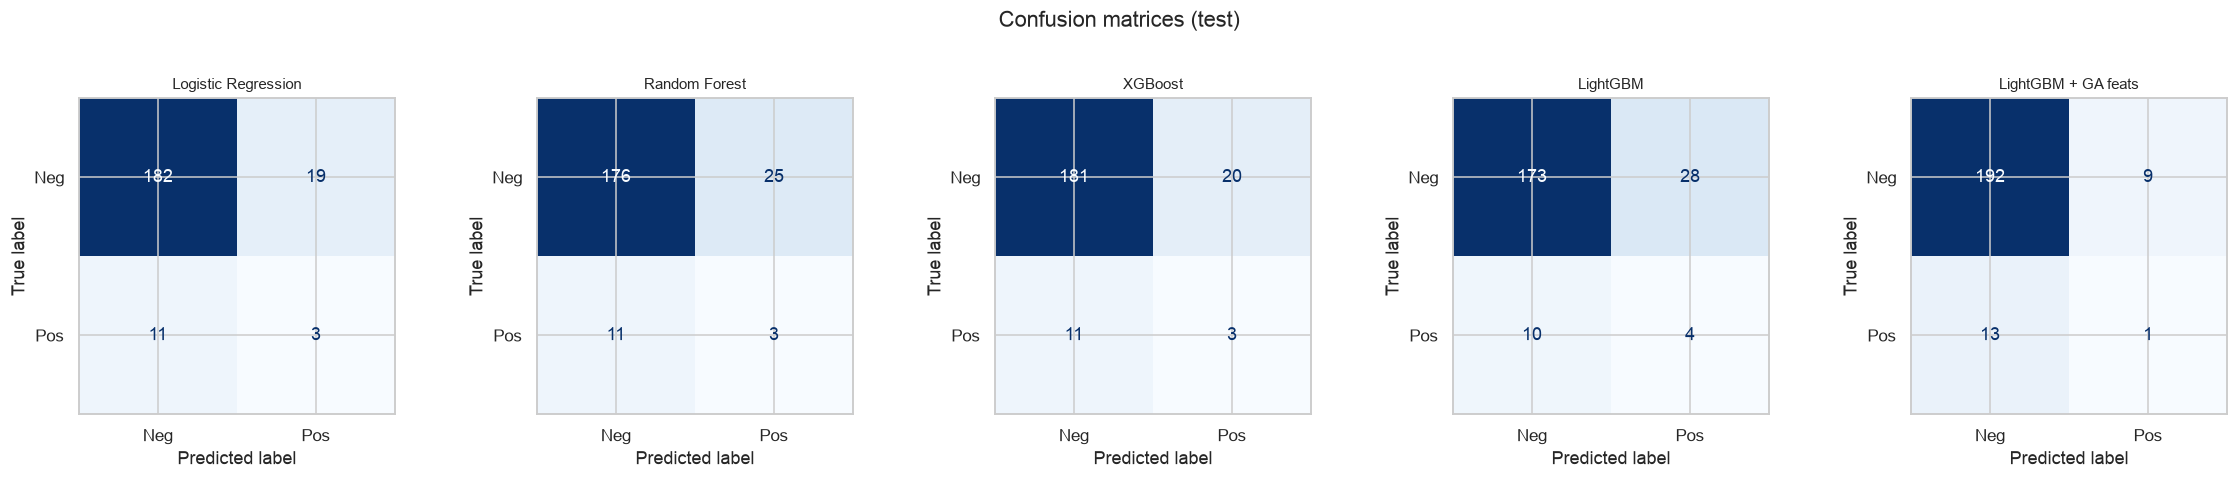

In [26]:
names = list(trained_models.keys())
fig, axes = plt.subplots(1, len(names), figsize=(4.2*len(names), 4))
if len(names) == 1: axes = [axes]
for ax, name in zip(axes, names):
    model = trained_models[name]
    Xt = X_test[features_ga] if "GA" in name else X_test
    proba = model.predict_proba(Xt)[:, 1]
    cm = confusion_matrix(y_test, (proba >= thresholds[name]).astype(int))  # tuned threshold
    ConfusionMatrixDisplay(cm, display_labels=["Neg", "Pos"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)
plt.suptitle("Confusion matrices (test)", y=1.05)
plt.tight_layout(); plt.show()

## Selection and justification of the best model
We sort by **PR-AUC** (with **Recall** as the clinical tie-breaker). The best model is the first one in the table; the next cell declares it automatically:

In [27]:
best_name = final_table.index[0]
best_row = final_table.iloc[0]
print(f"BEST MODEL: {best_name}")
print(f"   PR-AUC = {best_row['PR-AUC']:.4f} | ROC-AUC = {best_row['ROC-AUC']:.4f} "
      f"| Recall = {best_row['Recall']:.4f} | F1 = {best_row['F1']:.4f}")

BEST MODEL: Random Forest
   PR-AUC = 0.1945 | ROC-AUC = 0.7454 | Recall = 0.2143 | F1 = 0.1429


**Justification.** In medical screening we choose the model with the best **PR-AUC** that keeps a **high Recall**: we prefer to detect as many truly at-risk patients as possible, even at the cost of some false positives (which only imply an additional confirmatory study). Accuracy is ignored, because the trivial classifier already reaches ~93% without detecting any sick patient.

# Interpretability (SHAP)

SHAP decomposes each prediction into the contribution of each feature, allowing a clinical reading of the risk factors. We use a tree-based model (if the best one were logistic regression, we would also interpret its coefficients).

Explaining the model: LightGBM


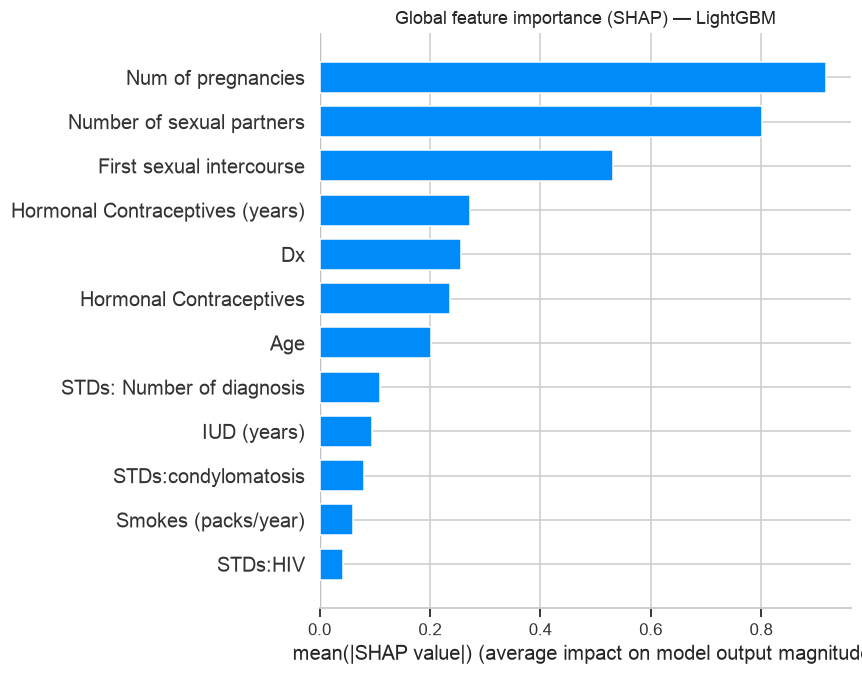

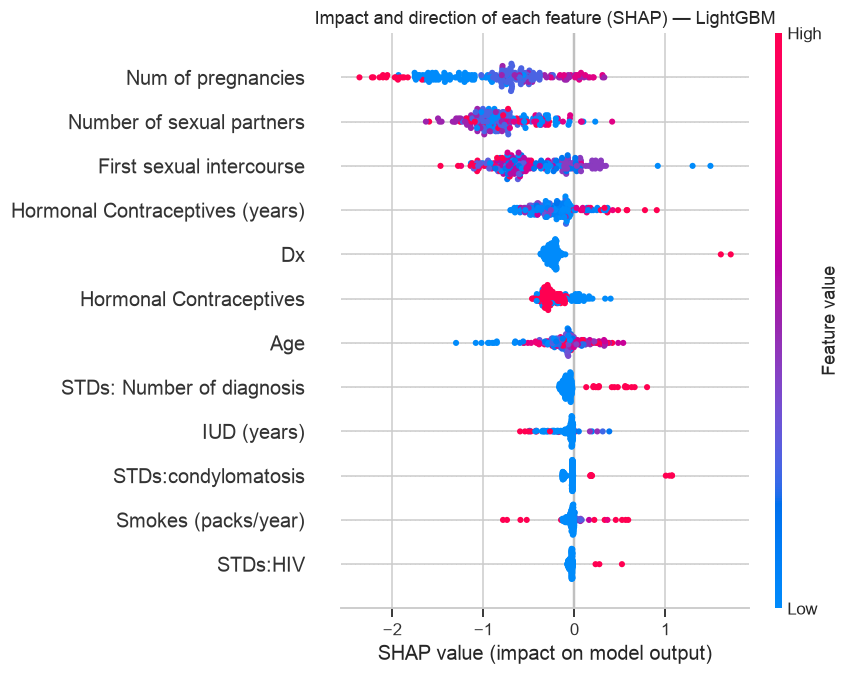

In [28]:
import shap

# We choose a tree-based model for SHAP (TreeExplainer is exact and fast with them)
tree_name = next((n for n in ["LightGBM", "XGBoost", "Random Forest"]
                  if n in trained_models), None)
shap_model = trained_models[tree_name]

# Preprocess the test set with ONLY imputer+scaler (SMOTE doesn't apply nor expose .transform)
from sklearn.pipeline import Pipeline as SkPipeline
transform_steps = [(n, t) for n, t in shap_model.steps if n in ("imputer", "scaler")]
pre = SkPipeline(transform_steps)
X_test_trans = pre.fit(X_train, y_train).transform(X_test)
X_test_trans = pd.DataFrame(X_test_trans, columns=X.columns)
final_clf = shap_model.named_steps["clf"]

explainer = shap.TreeExplainer(final_clf)
shap_values = explainer.shap_values(X_test_trans)
# Some models return a list [class0, class1]; we keep the positive class
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"Explaining the model: {tree_name}")
shap.summary_plot(sv, X_test_trans, plot_type="bar", show=False, max_display=12)
plt.title(f"Global feature importance (SHAP) — {tree_name}")
plt.tight_layout(); plt.show()

shap.summary_plot(sv, X_test_trans, show=False, max_display=12)
plt.title(f"Impact and direction of each feature (SHAP) — {tree_name}")
plt.tight_layout(); plt.show()

### Clinical interpretation (SHAP)
The most influential factors are consistent with the medical literature on cervical cancer: **prior diagnoses (`Dx:*`)**, **hormonal contraceptives**, and **age**, and **sexual behavior / STDs** (exposure to HPV, the main causal agent).

> **Warning:** the model is a support tool, not a substitute for medical judgment; the associations are correlational and come from a small, biased sample.

# Conclusions

### Key findings
- The **strong imbalance (~6.4% positives)** dominates the project: it forces the use of minority-class metrics (Recall, PR-AUC) and balancing (SMOTE) without *leakage*.
- The **cleaning** (`?`→NaN) and the **removal of leakage** (`Hinselmann`, `Schiller`, `Citology`) are critical: using them as features would give unrealistically high metrics that would not generalize.
- **Feature selection** —including the **genetic algorithm**— converges on a core of clinically sensible predictors: prior diagnoses, age, hormonal contraception, and sexual behavior / STDs.
- **Boosting ensembles** (XGBoost/LightGBM) and Random Forest offer the best PR-AUC/Recall balance, and **SHAP** provides a clinically coherent interpretation.

### Limitations
1. **Size and imbalance:** only **55 positive cases** ⇒ metrics with high variance.
2. **Sampling bias:** data from a single center; generalization is not guaranteed.
3. **Self-reported data:** possible errors or under-reporting in habits/behavior.
4. **SMOTE** generates synthetic samples; it mitigates the imbalance but does not create new information.

### Possible improvements
- Collect more positive data or combine cohorts from several centers.
- Set a target Recall (e.g., ≥ 0.90) by adjusting the threshold and report the resulting precision.
- Try modern tabular models (TabPFN, FT-Transformer) and probability calibration.
- External validation on an independent population before any clinical use.
- Explore asymmetric costs that penalize false negatives.